# Librerías

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pyspark.sql import SparkSession
from pyspark.sql import functions as F
from pyspark.sql import types as T
from pyspark.sql.types import (
    StructType,
    StructField,
    StringType,
    DoubleType,
    IntegerType
)
import os

os.environ["SPARK_LOCAL_HOSTNAME"] = "localhost"

# Sesión de Spark

In [2]:
spark = (
    SparkSession.builder
    .appName("Lab7_ENEIC")
    .getOrCreate()
)
print("Versión de Spark:", spark.version)

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/09/27 18:58:28 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Versión de Spark: 3.5.3


# Setup

In [3]:
archivos = {
    "2025T1": "datos/Personas_ENEIC_T1_2025.xlsx",
    "2025T2": "datos/Personas-ENEIC-T2-2025.xlsx",
    "2025T3": "datos/Base-de-datos-Personas-ENEIC-III-2025.xlsx",
    "2025T4": "datos/Base-de-datos-Personas-ENEIC-IV-2025.xlsx",
    "2026T1": "datos/Base-de-datos-Personas-ENEIC-I-2026.xlsx"
}

ruta_diccionario = "datos/Diccionario-Personas-ENEIC-I-2026.xlsx"

columnas = [
    "P05D01",       # salario mensual
    "P02A03",       # edad
    "P05C07A",      # antigüedad - años
    "P05C07B",      # antigüedad - meses
    "P05H01A",      # horas semanales
    "P03A03A",      # nivel educativo
    "P05C16",       # categoría ocupacional
    "DOMINIO",
    "OCUPADOS",
    "NUM_HOGAR",
    "NUM_PERSONA",
    "FACTOR",
    "ANIO",
    "TRIMESTRE"
]

ruta_t1_2025 = archivos["2025T1"]

excel_t1 = pd.ExcelFile(ruta_t1_2025)

print(excel_t1.sheet_names)

t1_2025_pd = pd.read_excel(
    ruta_t1_2025
)
print("Dimensiones:", t1_2025_pd.shape)

renombres = {
    "P05D01": "salario_mensual",
    "P02A03": "edad",
    "P05C07A": "antiguedad_anios",
    "P05C07B": "antiguedad_meses",
    "P05H01A": "horas_semanales",
    "P03A03A": "nivel_educativo",
    "P05C16": "categoria_ocupacional",
    "DOMINIO": "dominio",
    "OCUPADOS": "ocupado"
}

['Personas_ENEIC_T1_2025']


Dimensiones: (51588, 270)


In [4]:
def cargar_periodo(ruta, periodo, anio, trimestre):

    # Leer Excel
    df = pd.read_excel(ruta)

    # Guardar cantidad original
    n_original = len(df)

    # Seleccionar únicamente las columnas necesarias
    df = df[columnas].copy()

    # Renombrar variables analíticas
    df = df.rename(columns=renombres)

    # Agregar trazabilidad del archivo
    df["archivo_origen"] = ruta
    df["periodo_archivo"] = periodo
    df["anio_archivo"] = anio
    df["trimestre_calendario"] = trimestre

    # Homologar variables numéricas
    columnas_numericas = [
        "salario_mensual",
        "edad",
        "antiguedad_anios",
        "antiguedad_meses",
        "horas_semanales",
        "FACTOR"
    ]

    for col in columnas_numericas:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

    # Homologar códigos categóricos como strings
    columnas_categoricas = [
        "nivel_educativo",
        "categoria_ocupacional",
        "dominio",
        "ocupado"
    ]

    for col in columnas_categoricas:
        df[col] = (
            pd.to_numeric(df[col], errors="coerce")
            .astype("Int64")
            .astype("string")
        )

    # IDs para auditoría
    df["NUM_HOGAR"] = (
        df["NUM_HOGAR"]
        .astype("Int64")
        .astype("string")
    )

    df["NUM_PERSONA"] = (
        df["NUM_PERSONA"]
        .astype("Int64")
        .astype("string")
    )

    # Construir antigüedad en años
    df["antiguedad"] = (
        df["antiguedad_anios"]
        + df["antiguedad_meses"] / 12
    )

    return df, n_original

In [5]:
t1_2025, n_t1_2025 = cargar_periodo(
    archivos["2025T1"],
    "2025T1",
    2025,
    1
)

t2_2025, n_t2_2025 = cargar_periodo(
    archivos["2025T2"],
    "2025T2",
    2025,
    2
)

t3_2025, n_t3_2025 = cargar_periodo(
    archivos["2025T3"],
    "2025T3",
    2025,
    3
)

t4_2025, n_t4_2025 = cargar_periodo(
    archivos["2025T4"],
    "2025T4",
    2025,
    4
)

t1_2026, n_t1_2026 = cargar_periodo(
    archivos["2026T1"],
    "2026T1",
    2026,
    1
)

In [6]:
schema_eneic = StructType([
    StructField("salario_mensual", DoubleType(), True),
    StructField("edad", DoubleType(), True),
    StructField("antiguedad_anios", DoubleType(), True),
    StructField("antiguedad_meses", DoubleType(), True),
    StructField("horas_semanales", DoubleType(), True),

    StructField("nivel_educativo", StringType(), True),
    StructField("categoria_ocupacional", StringType(), True),
    StructField("dominio", StringType(), True),
    StructField("ocupado", StringType(), True),

    StructField("NUM_HOGAR", StringType(), True),
    StructField("NUM_PERSONA", StringType(), True),

    StructField("FACTOR", DoubleType(), True),

    StructField("ANIO", IntegerType(), True),
    StructField("TRIMESTRE", IntegerType(), True),

    StructField("archivo_origen", StringType(), True),
    StructField("periodo_archivo", StringType(), True),

    StructField("anio_archivo", IntegerType(), True),
    StructField("trimestre_calendario", IntegerType(), True),

    StructField("antiguedad", DoubleType(), True)
])

In [7]:
def preparar_para_spark(df):

    df = df.copy()

    # Variables continuas
    columnas_double = [
        "salario_mensual",
        "edad",
        "antiguedad_anios",
        "antiguedad_meses",
        "horas_semanales",
        "FACTOR",
        "antiguedad"
    ]

    for col in columnas_double:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

        df[col] = df[col].apply(
            lambda x: float(x) if pd.notna(x) else None
        )

    # Variables enteras
    columnas_int = [
        "ANIO",
        "TRIMESTRE",
        "anio_archivo",
        "trimestre_calendario"
    ]

    for col in columnas_int:
        df[col] = pd.to_numeric(
            df[col],
            errors="coerce"
        )

        df[col] = df[col].apply(
            lambda x: int(x) if pd.notna(x) else None
        )

    # Variables de texto
    columnas_string = [
        "nivel_educativo",
        "categoria_ocupacional",
        "dominio",
        "ocupado",
        "NUM_HOGAR",
        "NUM_PERSONA",
        "archivo_origen",
        "periodo_archivo"
    ]

    for col in columnas_string:
        df[col] = df[col].apply(
            lambda x: str(x) if pd.notna(x) else None
        )

    return df

In [8]:
spark_t1_2025 = spark.createDataFrame(
    preparar_para_spark(t1_2025).to_dict("records"),
    schema=schema_eneic
)

spark_t2_2025 = spark.createDataFrame(
    preparar_para_spark(t2_2025).to_dict("records"),
    schema=schema_eneic
)

spark_t3_2025 = spark.createDataFrame(
    preparar_para_spark(t3_2025).to_dict("records"),
    schema=schema_eneic
)

spark_t4_2025 = spark.createDataFrame(
    preparar_para_spark(t4_2025).to_dict("records"),
    schema=schema_eneic
)

spark_t1_2026 = spark.createDataFrame(
    preparar_para_spark(t1_2026).to_dict("records"),
    schema=schema_eneic
)

In [9]:
datos_2025 = (
    spark_t1_2025
    .unionByName(spark_t2_2025)
    .unionByName(spark_t3_2025)
    .unionByName(spark_t4_2025)
)



datos_2025.groupBy(
    "periodo_archivo"
).count().orderBy(
    "periodo_archivo"
).show()

+---------------+-----+
|periodo_archivo|count|
+---------------+-----+
|         2025T1|51588|
|         2025T2|51167|
|         2025T3|51583|
|         2025T4|49338|
+---------------+-----+



In [10]:
variables_analisis = [
    "salario_mensual",
    "edad",
    "antiguedad_anios",
    "antiguedad_meses",
    "antiguedad",
    "horas_semanales",
    "nivel_educativo",
    "categoria_ocupacional",
    "dominio",
    "ocupado",
    "NUM_HOGAR",
    "NUM_PERSONA",
    "FACTOR"
]

total_2025 = datos_2025.count()

faltantes = []

for col in variables_analisis:
    n_faltantes = datos_2025.filter(
        F.col(col).isNull() |
        F.isnan(F.col(col)) if dict(datos_2025.dtypes)[col] in ["double", "float"]
        else F.col(col).isNull()
    ).count()

    faltantes.append(
        (
            col,
            n_faltantes,
            round(n_faltantes / total_2025 * 100, 2)
        )
    )

faltantes_df = spark.createDataFrame(
    faltantes,
    ["variable", "faltantes", "porcentaje"]
)

faltantes_df.show(truncate=False)

+---------------------+---------+----------+
|variable             |faltantes|porcentaje|
+---------------------+---------+----------+
|salario_mensual      |150651   |73.97     |
|edad                 |0        |0.0       |
|antiguedad_anios     |115454   |56.69     |
|antiguedad_meses     |115454   |56.69     |
|antiguedad           |115454   |56.69     |
|horas_semanales      |115454   |56.69     |
|nivel_educativo      |26344    |12.93     |
|categoria_ocupacional|115454   |56.69     |
|dominio              |0        |0.0       |
|ocupado              |115454   |56.69     |
|NUM_HOGAR            |0        |0.0       |
|NUM_PERSONA          |0        |0.0       |
|FACTOR               |0        |0.0       |
+---------------------+---------+----------+



In [11]:
duplicados_clave = (
    datos_2025
    .groupBy(
        "periodo_archivo",
        "NUM_HOGAR",
        "NUM_PERSONA"
    )
    .count()
    .filter(F.col("count") > 1)
)

print(
    "Claves duplicadas:",
    duplicados_clave.count()
)

duplicados_clave.show(10, truncate=False)

Claves duplicadas: 0


+---------------+---------+-----------+-----+
|periodo_archivo|NUM_HOGAR|NUM_PERSONA|count|
+---------------+---------+-----------+-----+
+---------------+---------+-----------+-----+



In [12]:
resumen_filtros = []

df_filtrado = datos_2025

def aplicar_filtro(df, condicion, nombre):
    antes = df.count()

    nuevo = df.filter(condicion)

    despues = nuevo.count()

    resumen_filtros.append({
        "filtro": nombre,
        "antes": antes,
        "despues": despues,
        "excluidos": antes - despues
    })

    return nuevo

# 1. Edad válida
df_filtrado = aplicar_filtro(
    df_filtrado,
    F.col("edad").isNotNull() &
    (~F.isnan("edad")) &
    (F.col("edad") >= 15),
    "Edad >= 15 y válida"
)

# 2. Ocupados
df_filtrado = aplicar_filtro(
    df_filtrado,
    F.col("ocupado") == "1",
    "OCUPADOS = 1"
)

# 3. Asalariados
df_filtrado = aplicar_filtro(
    df_filtrado,
    F.col("categoria_ocupacional").isin(
        ["1", "2", "3", "4"]
    ),
    "Categoría ocupacional 1-4"
)

# 4. Salario válido y positivo
df_filtrado = aplicar_filtro(
    df_filtrado,
    F.col("salario_mensual").isNotNull() &
    (~F.isnan("salario_mensual")) &
    (F.col("salario_mensual") > 0),
    "Salario mensual > 0"
)

# 5. Años de antigüedad válidos
df_filtrado = aplicar_filtro(
    df_filtrado,
    F.col("antiguedad_anios").isNotNull() &
    (~F.isnan("antiguedad_anios")) &
    (F.col("antiguedad_anios") >= 0),
    "Antigüedad en años válida"
)

# 6. Meses válidos
df_filtrado = aplicar_filtro(
    df_filtrado,
    F.col("antiguedad_meses").isNotNull() &
    (~F.isnan("antiguedad_meses")) &
    (F.col("antiguedad_meses") >= 0) &
    (F.col("antiguedad_meses") <= 11) &
    (F.col("antiguedad_meses") == F.floor("antiguedad_meses")),
    "Meses de antigüedad entre 0 y 11"
)

# 7. Antigüedad <= edad
df_filtrado = aplicar_filtro(
    df_filtrado,
    F.col("antiguedad").isNotNull() &
    (~F.isnan("antiguedad")) &
    (F.col("antiguedad") >= 0) &
    (F.col("antiguedad") <= F.col("edad")),
    "Antigüedad <= edad"
)

# 8. Horas válidas
df_filtrado = aplicar_filtro(
    df_filtrado,
    F.col("horas_semanales").isNotNull() &
    (~F.isnan("horas_semanales")) &
    (F.col("horas_semanales") > 0) &
    (F.col("horas_semanales") <= 168),
    "0 < horas semanales <= 168"
)

resumen_filtros_pd = pd.DataFrame(
    resumen_filtros
)

resumen_filtros_pd

print(
    "Registros originales 2025:",
    total_2025
)

print(
    "Registros analíticos finales:",
    df_filtrado.count()
)

datos_2025_filtrados = df_filtrado

datos_2025_filtrados.groupBy(
    "periodo_archivo"
).count().orderBy(
    "periodo_archivo"
).show()

Registros originales 2025: 203676
Registros analíticos finales: 53025


+---------------+-----+
|periodo_archivo|count|
+---------------+-----+
|         2025T1|13419|
|         2025T2|13492|
|         2025T3|13450|
|         2025T4|12664|
+---------------+-----+



# Ejercicio 1. Carga, armonización y calidad de datos

A partir de este punto se completa la preparación de 2025 y 2026. Los cuatro trimestres de 2025 se mantienen unidos por nombre y los filtros se aplican en un orden fijo para poder contabilizar las exclusiones.


In [13]:
# Comparación de registros antes y después de los filtros en 2025
antes = (
    datos_2025.groupBy("periodo_archivo")
    .count()
    .withColumnRenamed("count", "antes")
)

despues = (
    datos_2025_filtrados.groupBy("periodo_archivo")
    .count()
    .withColumnRenamed("count", "despues")
)

comparacion_registros = (
    antes.join(despues, on="periodo_archivo", how="left")
    .withColumn("excluidos", F.col("antes") - F.col("despues"))
    .withColumn(
        "porcentaje_excluido",
        F.round(F.col("excluidos") / F.col("antes") * 100, 2)
    )
    .orderBy("periodo_archivo")
)

comparacion_registros.show(truncate=False)


+---------------+-----+-------+---------+-------------------+
|periodo_archivo|antes|despues|excluidos|porcentaje_excluido|
+---------------+-----+-------+---------+-------------------+
|2025T1         |51588|13419  |38169    |73.99              |
|2025T2         |51167|13492  |37675    |73.63              |
|2025T3         |51583|13450  |38133    |73.93              |
|2025T4         |49338|12664  |36674    |74.33              |
+---------------+-----+-------+---------+-------------------+



In [14]:
# Preparación de 2026 con exactamente las mismas reglas analíticas

def filtrar_poblacion(df):
    return (
        df
        .filter(F.col("edad").isNotNull() & (~F.isnan("edad")) & (F.col("edad") >= 15))
        .filter(F.col("ocupado") == "1")
        .filter(F.col("categoria_ocupacional").isin(["1", "2", "3", "4"]))
        .filter(
            F.col("salario_mensual").isNotNull() &
            (~F.isnan("salario_mensual")) &
            (F.col("salario_mensual") > 0)
        )
        .filter(
            F.col("antiguedad_anios").isNotNull() &
            (~F.isnan("antiguedad_anios")) &
            (F.col("antiguedad_anios") >= 0)
        )
        .filter(
            F.col("antiguedad_meses").isNotNull() &
            (~F.isnan("antiguedad_meses")) &
            (F.col("antiguedad_meses") >= 0) &
            (F.col("antiguedad_meses") <= 11) &
            (F.col("antiguedad_meses") == F.floor("antiguedad_meses"))
        )
        .filter(
            F.col("antiguedad").isNotNull() &
            (~F.isnan("antiguedad")) &
            (F.col("antiguedad") >= 0) &
            (F.col("antiguedad") <= F.col("edad"))
        )
        .filter(
            F.col("horas_semanales").isNotNull() &
            (~F.isnan("horas_semanales")) &
            (F.col("horas_semanales") > 0) &
            (F.col("horas_semanales") <= 168)
        )
    )

# Los faltantes categóricos no reconocidos se representan como DESCONOCIDO.
datos_2025_filtrados = (
    datos_2025_filtrados
    .fillna({"nivel_educativo": "DESCONOCIDO", "dominio": "DESCONOCIDO"})
    .cache()
)

datos_2026_filtrados = (
    filtrar_poblacion(spark_t1_2026)
    .fillna({"nivel_educativo": "DESCONOCIDO", "dominio": "DESCONOCIDO"})
    .cache()
)

print("Registros analíticos 2025:", datos_2025_filtrados.count())
print("Registros analíticos 2026 T1:", datos_2026_filtrados.count())


Registros analíticos 2025: 53025
Registros analíticos 2026 T1: 13258


In [15]:
# Verificación de unicidad de la clave en 2026

duplicados_clave_2026 = (
    spark_t1_2026
    .groupBy("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA")
    .count()
    .filter(F.col("count") > 1)
)

print("Claves duplicadas en 2026 T1:", duplicados_clave_2026.count())
duplicados_clave_2026.show(10, truncate=False)


Claves duplicadas en 2026 T1: 0


+---------------+---------+-----------+-----+
|periodo_archivo|NUM_HOGAR|NUM_PERSONA|count|
+---------------+---------+-----------+-----+
+---------------+---------+-----------+-----+



In [16]:
# Guardar los conjuntos preparados por separado en Parquet
import os
os.makedirs("datos_procesados", exist_ok=True)

datos_2025_filtrados.write.mode("overwrite").parquet(
    "datos_procesados/eneic_2025"
)

datos_2026_filtrados.write.mode("overwrite").parquet(
    "datos_procesados/eneic_2026T1"
)

print("Parquet de 2025 y 2026 guardados correctamente.")


26/09/27 19:04:45 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/27 19:04:45 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/27 19:04:45 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers


26/09/27 19:04:45 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/27 19:04:45 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers


26/09/27 19:04:45 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/27 19:04:45 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/27 19:04:45 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 76.00% for 10 writers
26/09/27 19:04:45 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 84.44% for 9 writers
26/09/27 19:04:45 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/27 19:04:45 WARN MemoryManager: Total allocation exceeds 95.00% (1,020,054,720 bytes) of heap memory
Scaling row group sizes to 95.00% for 8 writers
26/09/27 19:04:45 WARN MemoryManager: Total allocation exceeds 95.00%

Parquet de 2025 y 2026 guardados correctamente.


### Respuestas metodológicas del ejercicio 1

**¿Por qué IV de 2025 no puede apilarse por posición?** El cuarto trimestre contiene más columnas originales que los otros archivos. Por ello se seleccionaron y homologaron las variables requeridas y se utilizó `unionByName`, evitando depender de la posición física de las columnas.

**Ausencia por no correspondencia vs. respuesta no registrada.** Una pregunta puede no aplicar por el flujo del cuestionario; esto es distinto de una pregunta aplicable cuya respuesta no fue registrada. Ambos casos pueden aparecer como faltantes, pero no tienen el mismo significado.

**Observaciones repetidas entre períodos.** La ENEIC tiene diseño longitudinal con rotación. Una persona observada en dos períodos representa dos observaciones temporales y no debe eliminarse automáticamente como duplicado.

**Alcance de la base filtrada.** Los resultados describen únicamente los registros que cumplen los criterios analíticos y el análisis principal es no ponderado. Por ello no representan a todos los trabajadores del país. `FACTOR` se conserva para documentar el diseño muestral y sería necesario en estimaciones poblacionales.


# Ejercicio 2. Estadística descriptiva y análisis exploratorio


In [17]:
# Estadísticos descriptivos sobre todos los registros elegibles de 2025
variables_numericas_eda = [
    "salario_mensual", "edad", "antiguedad", "horas_semanales"
]

estadisticos = []

for v in variables_numericas_eda:
    fila = datos_2025_filtrados.select(
        F.lit(v).alias("variable"),
        F.count(F.col(v)).alias("n"),
        F.avg(v).alias("media"),
        F.expr(f"percentile_approx({v}, 0.5, 10000)").alias("mediana"),
        F.stddev(v).alias("desv_estandar"),
        F.min(v).alias("minimo"),
        F.expr(f"percentile_approx({v}, 0.25, 10000)").alias("p25"),
        F.expr(f"percentile_approx({v}, 0.75, 10000)").alias("p75"),
        F.expr(f"percentile_approx({v}, 0.95, 10000)").alias("p95"),
        F.max(v).alias("maximo")
    )
    estadisticos.append(fila)

tabla_estadisticos = estadisticos[0]
for tabla in estadisticos[1:]:
    tabla_estadisticos = tabla_estadisticos.unionByName(tabla)

tabla_estadisticos.show(truncate=False)


+---------------+-----+------------------+-------+------------------+------+------+------+------+-------+
|variable       |n    |media             |mediana|desv_estandar     |minimo|p25   |p75   |p95   |maximo |
+---------------+-----+------------------+-------+------------------+------+------+------+------+-------+
|salario_mensual|53025|3421.6842055634133|3000.0 |2902.10896382208  |1.0   |1800.0|4000.0|8000.0|99000.0|
|edad           |53025|35.187647336162186|33.0   |13.520901607119617|15.0  |24.0  |44.0  |61.0  |89.0   |
|antiguedad     |53025|5.558827597045418 |2.0    |7.8310171787565945|0.0   |0.5   |7.0   |22.0  |70.0   |
|horas_semanales|53025|46.30740216878831 |45.0   |18.63040684352504 |1.0   |40.0  |55.0  |80.0  |126.0  |
+---------------+-----+------------------+-------+------------------+------+------+------+------+-------+



In [18]:
# Distribución de registros por categoría ocupacional, nivel educativo y dominio
for variable in ["categoria_ocupacional", "nivel_educativo", "dominio"]:
    print(f"\nDistribución de {variable}")
    (
        datos_2025_filtrados
        .groupBy(variable)
        .count()
        .withColumn(
            "porcentaje",
            F.round(F.col("count") / F.lit(datos_2025_filtrados.count()) * 100, 2)
        )
        .orderBy(F.desc("count"))
        .show(50, truncate=False)
    )



Distribución de categoria_ocupacional


+---------------------+-----+----------+
|categoria_ocupacional|count|porcentaje|
+---------------------+-----+----------+
|2                    |28702|54.13     |
|3                    |13842|26.1      |
|1                    |6575 |12.4      |
|4                    |3906 |7.37      |
+---------------------+-----+----------+


Distribución de nivel_educativo


+---------------+-----+----------+
|nivel_educativo|count|porcentaje|
+---------------+-----+----------+
|4              |16851|31.78     |
|2              |15822|29.84     |
|3              |8249 |15.56     |
|5              |6818 |12.86     |
|0              |3995 |7.53      |
|6              |771  |1.45      |
|1              |459  |0.87      |
|7              |60   |0.11      |
+---------------+-----+----------+


Distribución de dominio


+-------+-----+----------+
|dominio|count|porcentaje|
+-------+-----+----------+
|1      |22072|41.63     |
|2      |20146|37.99     |
|3      |10807|20.38     |
+-------+-----+----------+



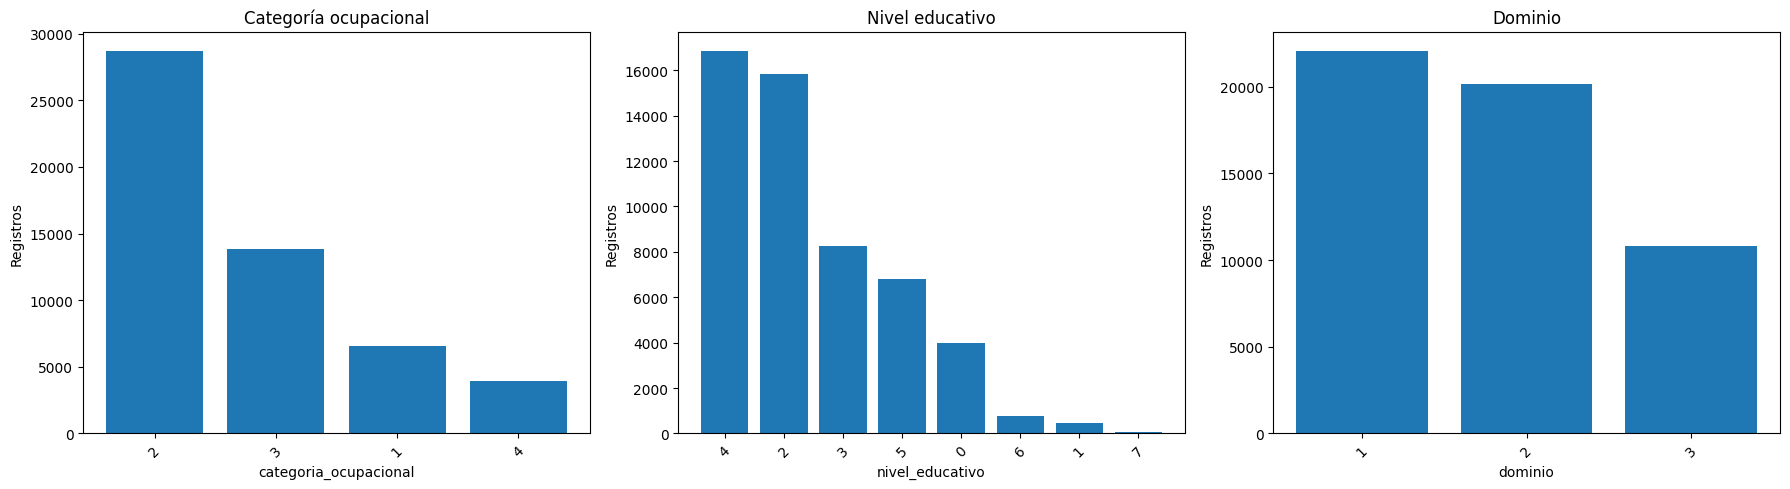

In [19]:
# Gráficas de las variables categóricas usando únicamente tablas agregadas
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, variable, titulo in zip(
    axes,
    ["categoria_ocupacional", "nivel_educativo", "dominio"],
    ["Categoría ocupacional", "Nivel educativo", "Dominio"]
):
    tabla = (
        datos_2025_filtrados.groupBy(variable).count()
        .orderBy(F.desc("count"))
        .toPandas()
    )
    ax.bar(tabla[variable].astype(str), tabla["count"])
    ax.set_title(titulo)
    ax.set_xlabel(variable)
    ax.set_ylabel("Registros")
    ax.tick_params(axis="x", rotation=45)

plt.tight_layout()
plt.show()


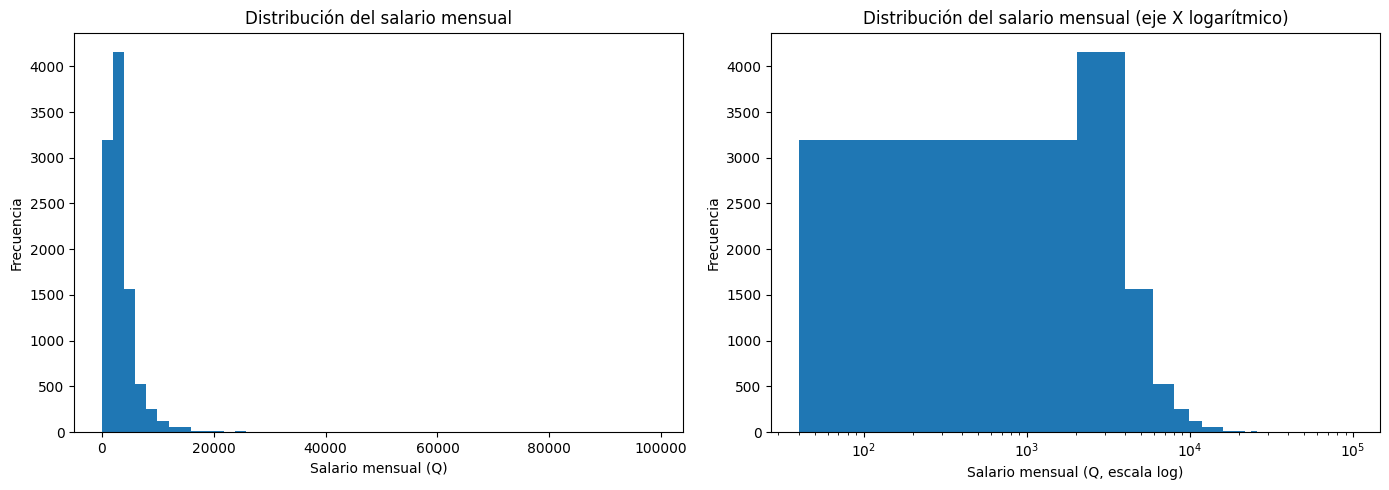

In [20]:
# Distribución del salario. Se usa una muestra solo para dibujar; las estadísticas anteriores usan todos los registros.

muestra_salario = (
    datos_2025_filtrados
    .select("salario_mensual")
    .sample(withReplacement=False, fraction=min(1.0, 10000 / datos_2025_filtrados.count()), seed=42)
    .limit(10000)
    .toPandas()
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].hist(muestra_salario["salario_mensual"], bins=50)
axes[0].set_title("Distribución del salario mensual")
axes[0].set_xlabel("Salario mensual (Q)")
axes[0].set_ylabel("Frecuencia")

axes[1].hist(muestra_salario["salario_mensual"], bins=50)
axes[1].set_xscale("log")
axes[1].set_title("Distribución del salario mensual (eje X logarítmico)")
axes[1].set_xlabel("Salario mensual (Q, escala log)")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.show()


In [21]:
# Salario mediano por nivel educativo y categoría ocupacional

mediana_educacion = (
    datos_2025_filtrados
    .groupBy("nivel_educativo")
    .agg(
        F.count("*").alias("n"),
        F.expr("percentile_approx(salario_mensual, 0.5, 10000)").alias("salario_mediano")
    )
    .orderBy(F.desc("salario_mediano"))
)

mediana_ocupacion = (
    datos_2025_filtrados
    .groupBy("categoria_ocupacional")
    .agg(
        F.count("*").alias("n"),
        F.expr("percentile_approx(salario_mensual, 0.5, 10000)").alias("salario_mediano")
    )
    .orderBy(F.desc("salario_mediano"))
)

print("Salario mediano por nivel educativo")
mediana_educacion.show(50, truncate=False)
print("Salario mediano por categoría ocupacional")
mediana_ocupacion.show(20, truncate=False)


Salario mediano por nivel educativo


+---------------+-----+---------------+
|nivel_educativo|n    |salario_mediano|
+---------------+-----+---------------+
|7              |60   |12000.0        |
|6              |771  |10000.0        |
|5              |6818 |5000.0         |
|4              |16851|3600.0         |
|3              |8249 |2800.0         |
|2              |15822|2200.0         |
|1              |459  |2160.0         |
|0              |3995 |1500.0         |
+---------------+-----+---------------+

Salario mediano por categoría ocupacional


+---------------------+-----+---------------+
|categoria_ocupacional|n    |salario_mediano|
+---------------------+-----+---------------+
|1                    |6575 |5000.0         |
|2                    |28702|3560.0         |
|3                    |13842|1800.0         |
|4                    |3906 |1000.0         |
+---------------------+-----+---------------+



+---------------+-----+------------------+---------------+
|periodo_archivo|n    |salario_medio     |salario_mediano|
+---------------+-----+------------------+---------------+
|2025T1         |13419|3315.631939786869 |3000.0         |
|2025T2         |13492|3364.570782686036 |3000.0         |
|2025T3         |13450|3469.0746468401485|3200.0         |
|2025T4         |12664|3544.574936828806 |3200.0         |
+---------------+-----+------------------+---------------+



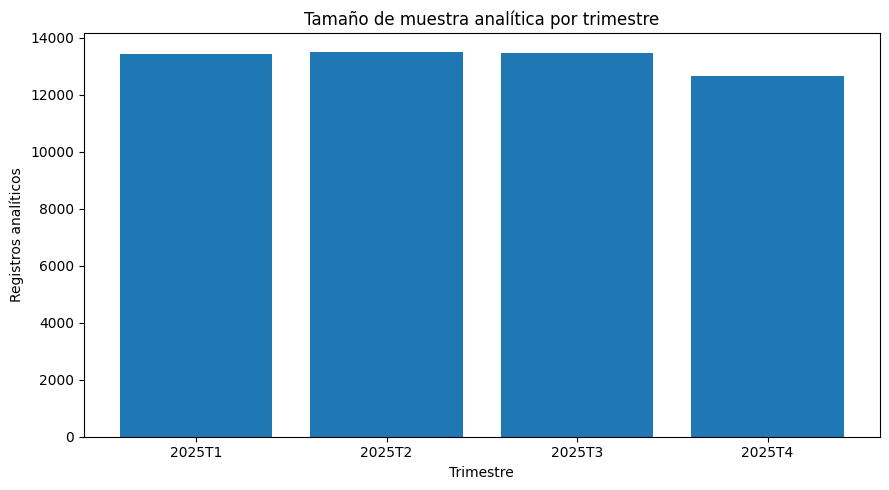

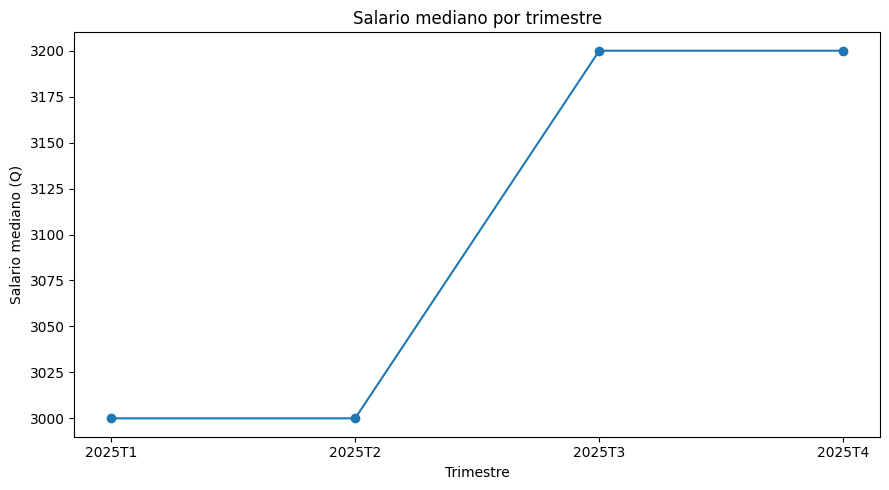

In [22]:
# Tamaño de muestra y salario mediano por trimestre
resumen_trimestre = (
    datos_2025_filtrados
    .groupBy("periodo_archivo")
    .agg(
        F.count("*").alias("n"),
        F.avg("salario_mensual").alias("salario_medio"),
        F.expr("percentile_approx(salario_mensual, 0.5, 10000)").alias("salario_mediano")
    )
    .orderBy("periodo_archivo")
)

resumen_trimestre.show(truncate=False)

trimestre_pd = resumen_trimestre.toPandas()
fig, ax1 = plt.subplots(figsize=(9, 5))
ax1.bar(trimestre_pd["periodo_archivo"], trimestre_pd["n"])
ax1.set_xlabel("Trimestre")
ax1.set_ylabel("Registros analíticos")
ax1.set_title("Tamaño de muestra analítica por trimestre")
plt.tight_layout()
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(trimestre_pd["periodo_archivo"], trimestre_pd["salario_mediano"], marker="o")
plt.title("Salario mediano por trimestre")
plt.xlabel("Trimestre")
plt.ylabel("Salario mediano (Q)")
plt.tight_layout()
plt.show()


### Interpretación del ejercicio 2

La categoría ocupacional se concentra en empleados de empresa privada, con 54.1% de los 53,025 registros analíticos de 2025, seguida por jornaleros o peones con 26.1%, empleados de gobierno con 12.4% y servicio doméstico con 7.4%. En nivel educativo, casi el 62% de las personas están en los códigos 2 y 4, y solo el 7.5% no tiene ningún nivel educativo (código 0). El dominio 1 concentra el 41.6% de los registros, el dominio 2 el 38%, y el dominio 3 el 20.4%.

**El salario es asimétrico a la derecha.** La media es de Q3,421.68 y la mediana es de Q3,000. La media es más alta porque un grupo pequeño de salarios muy altos (el máximo observado es Q99,000, y el percentil 95 ya es Q8,000) estira el promedio hacia arriba, mientras que la mediana no se ve afectada por esos valores extremos. Esta diferencia de casi Q422 entre media y mediana confirma que el salario no se distribuye de forma simétrica.

**El salario mediano crece con el nivel educativo.** Va de Q1,500 en el código 0 (ninguno) hasta Q12,000 en el código más alto, con un salto grande a partir del código 5 (Q5,000) en adelante. Por categoría ocupacional, el salario mediano más alto es el de empleados de gobierno (Q5,000), seguido de empresa privada (Q3,560), jornalero o peón (Q1,800) y servicio doméstico (Q1,000), que es el más bajo.

**Entre trimestres, la muestra analítica baja un poco y el salario mediano sube un poco.** El tamaño pasa de 13,419 registros en 2025T1 a 12,664 en 2025T4, mientras que el salario mediano pasa de Q3,000 en los primeros dos trimestres a Q3,200 en el tercero y cuarto. Este aumento es en términos nominales y puede reflejar tanto inflación como cambios estacionales en el mercado laboral, no necesariamente una mejora real en el poder adquisitivo.

# Ejercicio 3. Relaciones entre variables numéricas


26/09/27 19:04:52 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.JNIBLAS
26/09/27 19:04:52 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.blas.VectorBLAS


,salario_mensual,edad,antiguedad,horas_semanales
salario_mensual,1.000,0.147,0.180,0.076
edad,0.147,1.000,0.487,-0.105
antiguedad,0.180,0.487,1.000,-0.062
horas_semanales,0.076,-0.105,-0.062,1.000


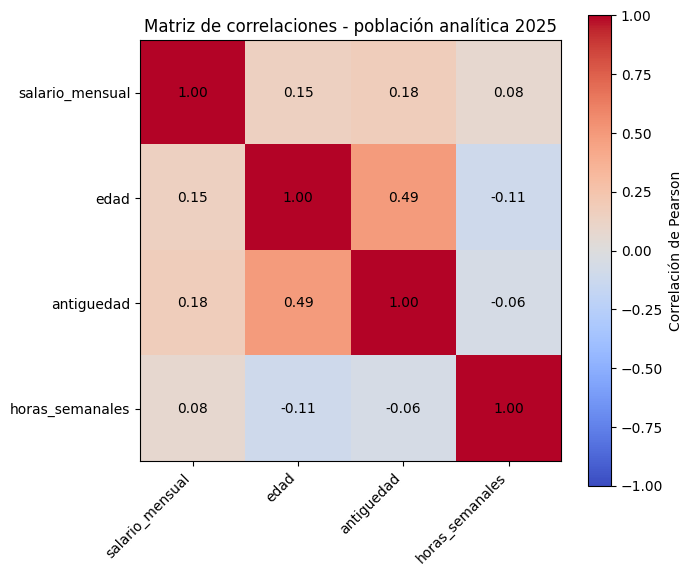

In [23]:
from pyspark.ml.feature import VectorAssembler
from pyspark.ml.stat import Correlation

variables_correlacion = [
    "salario_mensual", "edad", "antiguedad", "horas_semanales"
]

assembler_corr = VectorAssembler(
    inputCols=variables_correlacion,
    outputCol="features_corr",
    handleInvalid="skip"
)

datos_corr = assembler_corr.transform(datos_2025_filtrados).select("features_corr")

matriz = Correlation.corr(datos_corr, "features_corr", "pearson").head()[0]
matriz_np = matriz.toArray()

corr_pd = pd.DataFrame(
    matriz_np,
    index=variables_correlacion,
    columns=variables_correlacion
)

display(corr_pd.round(3))

plt.figure(figsize=(7, 6))
plt.imshow(corr_pd, vmin=-1, vmax=1, cmap="coolwarm")
plt.colorbar(label="Correlación de Pearson")
plt.xticks(range(len(variables_correlacion)), variables_correlacion, rotation=45, ha="right")
plt.yticks(range(len(variables_correlacion)), variables_correlacion)

for i in range(len(variables_correlacion)):
    for j in range(len(variables_correlacion)):
        plt.text(j, i, f"{corr_pd.iloc[i, j]:.2f}", ha="center", va="center")

plt.title("Matriz de correlaciones - población analítica 2025")
plt.tight_layout()
plt.show()


### Interpretación del ejercicio 3

**La antigüedad es la que más se asocia linealmente con el salario**, con una correlación de 0.180, seguida muy de cerca por la edad con 0.147. Las horas semanales son las que menos se asocian, con apenas 0.076. En los tres casos la asociación lineal es débil, lo que indica que el salario depende de otros factores además de estas tres variables, como el nivel educativo y la categoría ocupacional vistos en el ejercicio 2.

**Sí existe relación entre edad y antigüedad**, con una correlación de 0.487, la más alta de toda la matriz. Tiene sentido que las personas de mayor edad lleven en promedio más tiempo en su trabajo actual. Esta correlación es una asociación observada y no implica que envejecer cause directamente mayor antigüedad laboral.

# Ejercicio 4. Segmentación de perfiles mediante KMeans

Se comparan dos alternativas: una segmentación basada únicamente en edad, antigüedad y horas habituales, y otra que además incorpora salario mensual. Esto permite evaluar empíricamente si incluir salario mejora la separación de los perfiles. Todas las variables se estandarizan antes de KMeans.


In [24]:
from pyspark.ml.feature import VectorAssembler, StandardScaler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

escenarios_cluster = {
    "sin_salario": ["edad", "antiguedad", "horas_semanales"],
    "con_salario": ["edad", "antiguedad", "horas_semanales", "salario_mensual"]
}

resultados_k = []
modelos_k = {}
datos_clusterizados = {}

evaluador = ClusteringEvaluator(
    predictionCol="prediction",
    featuresCol="features_scaled",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

for escenario, variables in escenarios_cluster.items():
    assembler = VectorAssembler(
        inputCols=variables,
        outputCol="features_raw",
        handleInvalid="skip"
    )
    base = assembler.transform(datos_2025_filtrados)

    scaler = StandardScaler(
        inputCol="features_raw",
        outputCol="features_scaled",
        withStd=True,
        withMean=True
    )
    scaler_model = scaler.fit(base)
    base_scaled = scaler_model.transform(base).cache()

    for k in [2, 3, 4, 5]:
        kmeans = KMeans(
            k=k,
            seed=42,
            featuresCol="features_scaled",
            predictionCol="prediction"
        )
        modelo = kmeans.fit(base_scaled)
        pred = modelo.transform(base_scaled)
        silhouette = evaluador.evaluate(pred)

        resultados_k.append({
            "escenario": escenario,
            "k": k,
            "silhouette": silhouette
        })
        modelos_k[(escenario, k)] = modelo
        datos_clusterizados[(escenario, k)] = pred

resultados_k_pd = pd.DataFrame(resultados_k).sort_values(
    ["escenario", "k"]
)
resultados_k_pd


,escenario,k,silhouette
4,con_salario,2,0.513741
5,con_salario,3,0.490933
6,con_salario,4,0.375808
7,con_salario,5,0.382762
0,sin_salario,2,0.554482
1,sin_salario,3,0.413710
2,sin_salario,4,0.432372
3,sin_salario,5,0.442127


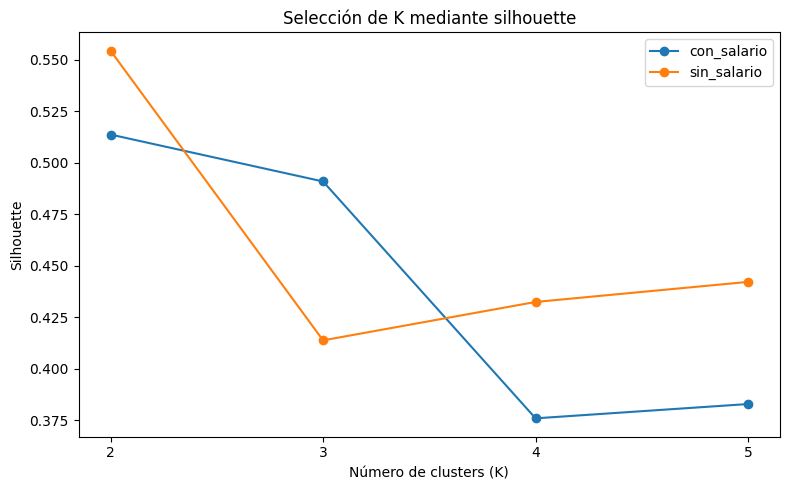

Mejor escenario: sin_salario
Mejor K: 2
Silhouette: 0.5545


In [25]:
# Visualización del criterio de selección de K
plt.figure(figsize=(8, 5))
for escenario in resultados_k_pd["escenario"].unique():
    sub = resultados_k_pd[resultados_k_pd["escenario"] == escenario]
    plt.plot(sub["k"], sub["silhouette"], marker="o", label=escenario)

plt.xlabel("Número de clusters (K)")
plt.ylabel("Silhouette")
plt.title("Selección de K mediante silhouette")
plt.xticks([2, 3, 4, 5])
plt.legend()
plt.tight_layout()
plt.show()

mejor = resultados_k_pd.loc[resultados_k_pd["silhouette"].idxmax()]
mejor_escenario = mejor["escenario"]
mejor_k = int(mejor["k"])

print("Mejor escenario:", mejor_escenario)
print("Mejor K:", mejor_k)
print("Silhouette:", round(mejor["silhouette"], 4))


In [26]:
# Caracterización de los clusters seleccionados
from pyspark.sql.window import Window

pred_final = datos_clusterizados[(mejor_escenario, mejor_k)]

perfil_clusters = (
    pred_final
    .groupBy("prediction")
    .agg(
        F.count("*").alias("n"),
        F.avg("edad").alias("edad_media"),
        F.avg("antiguedad").alias("antiguedad_media"),
        F.avg("horas_semanales").alias("horas_media"),
        F.avg("salario_mensual").alias("salario_medio"),
        F.expr("percentile_approx(salario_mensual, 0.5, 10000)").alias("salario_mediano")
    )
    .orderBy("prediction")
)

perfil_clusters.show(truncate=False)

# Distribuciones categóricas por cluster para ayudar a describir los perfiles
for variable in ["nivel_educativo", "categoria_ocupacional", "dominio"]:
    print(f"\n{variable} por cluster")
    (
        pred_final
        .groupBy("prediction", variable)
        .count()
        .withColumn(
            "total_cluster",
            F.sum("count").over(Window.partitionBy("prediction"))
        )
        .withColumn(
            "porcentaje_cluster",
            F.round(F.col("count") / F.col("total_cluster") * 100, 2)
        )
        .orderBy("prediction", F.desc("count"))
        .show(100, truncate=False)
    )


+----------+-----+------------------+-----------------+-----------------+------------------+---------------+
|prediction|n    |edad_media        |antiguedad_media |horas_media      |salario_medio     |salario_mediano|
+----------+-----+------------------+-----------------+-----------------+------------------+---------------+
|0         |14604|51.279101615995614|13.80502487902858|41.29553546973432|4068.515269789099 |3456.0         |
|1         |38421|29.071211056453503|2.424409827958668|48.21243590744645|3175.8207230420862|3000.0         |
+----------+-----+------------------+-----------------+-----------------+------------------+---------------+


nivel_educativo por cluster


+----------+---------------+-----+-------------+------------------+
|prediction|nivel_educativo|count|total_cluster|porcentaje_cluster|
+----------+---------------+-----+-------------+------------------+
|0         |2              |4749 |14604        |32.52             |
|0         |4              |3295 |14604        |22.56             |
|0         |5              |2491 |14604        |17.06             |
|0         |0              |2116 |14604        |14.49             |
|0         |3              |1392 |14604        |9.53              |
|0         |6              |345  |14604        |2.36              |
|0         |1              |168  |14604        |1.15              |
|0         |7              |48   |14604        |0.33              |
|1         |4              |13556|38421        |35.28             |
|1         |2              |11073|38421        |28.82             |
|1         |3              |6857 |38421        |17.85             |
|1         |5              |4327 |38421        |

+----------+---------------------+-----+-------------+------------------+
|prediction|categoria_ocupacional|count|total_cluster|porcentaje_cluster|
+----------+---------------------+-----+-------------+------------------+
|0         |2                    |6214 |14604        |42.55             |
|0         |3                    |3549 |14604        |24.3              |
|0         |1                    |3430 |14604        |23.49             |
|0         |4                    |1411 |14604        |9.66              |
|1         |2                    |22488|38421        |58.53             |
|1         |3                    |10293|38421        |26.79             |
|1         |1                    |3145 |38421        |8.19              |
|1         |4                    |2495 |38421        |6.49              |
+----------+---------------------+-----+-------------+------------------+


dominio por cluster
+----------+-------+-----+-------------+------------------+
|prediction|dominio|count|tota

### Interpretación del ejercicio 4

**El mejor resultado es K=2 sin incluir el salario**, con un silhouette de 0.5545. Incluir el salario baja el silhouette en K=2 a 0.5137, y en general los resultados con salario no superan de forma consistente a los resultados sin salario. Esto indica que no vale la pena incluir el salario en el clustering, la edad, la antigüedad y las horas semanales ya separan bien los grupos por sí solas, y el salario queda mejor como una variable para describir los clusters después, en vez de usarlo para construirlos.

**Cluster 0, perfil consolidado (14,604 personas, 27.5% de la muestra).** Edad media de 51 años, antigüedad media de casi 14 años, jornada de 41 horas semanales y salario mediano de Q3,456. Tiene una proporción de empleados de gobierno más alta que el otro cluster (23.5% contra 8.2%) y más presencia de niveles educativos altos.

**Cluster 1, perfil de reciente ingreso (38,421 personas, 72.5% de la muestra).** Edad media de 29 años, antigüedad media de apenas 2.4 años, jornada más larga de 48 horas semanales y salario mediano de Q3,000, más bajo que el cluster 0. Está dominado por empleados de empresa privada (58.5%).

En conjunto, los dos clusters describen una diferencia entre trabajadores con más años de carrera y estabilidad, y trabajadores más jóvenes con menos tiempo en su puesto actual. Esta descripción es válida solo para el grupo de asalariados analizado y no implica que estas categorías existan de forma natural en la población.

# Ejercicio 5. Pipeline de regresión lineal

Se separan los cuatro trimestres de 2025 en entrenamiento (2025T1 a 2025T3) y validación (2025T4), tal como lo indica la tabla de uso de los datos. El modelo de referencia predice el salario medio del entrenamiento para toda persona. La regresión lineal se compara contra ese modelo de referencia.

In [27]:
entrenamiento_2025 = datos_2025_filtrados.filter(
    F.col("periodo_archivo").isin(["2025T1", "2025T2", "2025T3"])
).cache()

validacion_2025 = datos_2025_filtrados.filter(
    F.col("periodo_archivo") == "2025T4"
).cache()

print("Registros de entrenamiento:", entrenamiento_2025.count())
print("Registros de validación:", validacion_2025.count())

Registros de entrenamiento: 40361
Registros de validación: 12664


In [28]:
from pyspark.ml.evaluation import RegressionEvaluator

evaluador_mae = RegressionEvaluator(labelCol="salario_mensual", predictionCol="prediction", metricName="mae")
evaluador_rmse = RegressionEvaluator(labelCol="salario_mensual", predictionCol="prediction", metricName="rmse")
evaluador_r2 = RegressionEvaluator(labelCol="salario_mensual", predictionCol="prediction", metricName="r2")

def evaluar_modelo(predicciones):
    return {
        "MAE": evaluador_mae.evaluate(predicciones),
        "RMSE": evaluador_rmse.evaluate(predicciones),
        "R2": evaluador_r2.evaluate(predicciones)
    }

salario_medio_entrenamiento = entrenamiento_2025.agg(F.avg("salario_mensual")).first()[0]

predicciones_referencia_validacion = validacion_2025.withColumn(
    "prediction", F.lit(salario_medio_entrenamiento)
)

metricas_referencia_validacion = evaluar_modelo(predicciones_referencia_validacion)
metricas_referencia_validacion

{'MAE': 1672.5026056434942,
 'RMSE': 2889.571432265965,
 'R2': -0.0031316038524971113}

In [29]:
from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, OneHotEncoder
from pyspark.ml.regression import LinearRegression

variables_categoricas = ["nivel_educativo", "categoria_ocupacional", "dominio"]
variables_numericas = ["edad", "antiguedad", "horas_semanales"]

indexadores = [
    StringIndexer(inputCol=col, outputCol=f"{col}_idx", handleInvalid="keep")
    for col in variables_categoricas
]

codificador = OneHotEncoder(
    inputCols=[f"{col}_idx" for col in variables_categoricas],
    outputCols=[f"{col}_ohe" for col in variables_categoricas],
    handleInvalid="keep"
)

ensamblador = VectorAssembler(
    inputCols=variables_numericas + [f"{col}_ohe" for col in variables_categoricas],
    outputCol="features"
)

configuraciones_lr = [
    {"regParam": 0.0, "elasticNetParam": 0.0},
    {"regParam": 0.1, "elasticNetParam": 0.0}
]

resultados_lr = []
modelos_lr = {}

for config in configuraciones_lr:
    lr = LinearRegression(
        featuresCol="features",
        labelCol="salario_mensual",
        regParam=config["regParam"],
        elasticNetParam=config["elasticNetParam"],
        standardization=True
    )
    pipeline_lr = Pipeline(stages=indexadores + [codificador, ensamblador, lr])
    modelo = pipeline_lr.fit(entrenamiento_2025)
    predicciones = modelo.transform(validacion_2025)
    metricas = evaluar_modelo(predicciones)
    metricas.update(config)
    resultados_lr.append(metricas)
    modelos_lr[(config["regParam"], config["elasticNetParam"])] = modelo

resultados_lr_pd = pd.DataFrame(resultados_lr)
resultados_lr_pd

26/09/27 19:05:10 WARN Instrumentation: [ec0af36f] regParam is zero, which might cause numerical instability and overfitting.


26/09/27 19:05:10 WARN InstanceBuilder: Failed to load implementation from:dev.ludovic.netlib.lapack.JNILAPACK
26/09/27 19:05:10 WARN Instrumentation: [ec0af36f] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


,MAE,RMSE,R2,regParam,elasticNetParam
0,1210.137480,2186.419579,0.425675,0.0,0.0
1,1210.132737,2186.420865,0.425674,0.1,0.0


In [30]:
mejor_fila_lr = resultados_lr_pd.loc[resultados_lr_pd["RMSE"].idxmin()]
mejor_config_lr = (mejor_fila_lr["regParam"], mejor_fila_lr["elasticNetParam"])
modelo_lr_validacion = modelos_lr[mejor_config_lr]

os.makedirs("modelos", exist_ok=True)
modelo_lr_validacion.write().overwrite().save("modelos/regresion_lineal_validacion")

comparacion_lr_referencia = pd.DataFrame([
    {"modelo": "Modelo de referencia", **metricas_referencia_validacion},
    {"modelo": "Regresión lineal", "MAE": mejor_fila_lr["MAE"], "RMSE": mejor_fila_lr["RMSE"], "R2": mejor_fila_lr["R2"]}
])

print("Mejor configuración de regresión lineal:", mejor_config_lr)
comparacion_lr_referencia

Mejor configuración de regresión lineal: (np.float64(0.0), np.float64(0.0))


,modelo,MAE,RMSE,R2
0,Modelo de referencia,1672.502606,2889.571432,-0.003132
1,Regresión lineal,1210.137480,2186.419579,0.425675


### Interpretación del ejercicio 5

**La configuración sin regularización (regParam=0.0) tuvo el menor RMSE de validación**, con 2,186.42, aunque la diferencia frente a regParam=0.1 es mínima (2,186.42 contra 2,186.42, prácticamente empatados). Con solo seis predictores y un tamaño de entrenamiento de 40,361 registros no hay señales de sobreajuste, así que agregar regularización no cambia el resultado de forma notable.

**La regresión lineal mejora bastante al modelo de referencia.** El modelo de referencia, que predice el salario medio de entrenamiento para todos, tiene un MAE de Q1,672.50, un RMSE de Q2,889.57 y un R² de -0.003, es decir que no explica nada de la variación del salario. La regresión lineal baja el MAE a Q1,210.14 y el RMSE a Q2,186.42, y alcanza un R² de 0.426. Esto significa que las seis variables usadas (edad, antigüedad, horas semanales, nivel educativo, categoría ocupacional y dominio) explican poco más del 42% de la variación del salario mensual en el conjunto de validación, una mejora clara frente al modelo de referencia pero lejos de una predicción perfecta.

# Ejercicio 6. Pipeline de Random Forest

Se reutilizan los mismos conjuntos de entrenamiento y validación del ejercicio anterior, y la misma codificación de variables categóricas. El Random Forest no necesita estandarización de los predictores.

In [31]:
from pyspark.ml.regression import RandomForestRegressor

configuraciones_rf = [
    {"numTrees": 50, "maxDepth": 5},
    {"numTrees": 100, "maxDepth": 10}
]

resultados_rf = []
modelos_rf = {}

for config in configuraciones_rf:
    rf = RandomForestRegressor(
        featuresCol="features",
        labelCol="salario_mensual",
        numTrees=config["numTrees"],
        maxDepth=config["maxDepth"],
        seed=42
    )
    pipeline_rf = Pipeline(stages=indexadores + [codificador, ensamblador, rf])
    modelo = pipeline_rf.fit(entrenamiento_2025)
    predicciones = modelo.transform(validacion_2025)
    metricas = evaluar_modelo(predicciones)
    metricas.update(config)
    resultados_rf.append(metricas)
    modelos_rf[(config["numTrees"], config["maxDepth"])] = modelo

resultados_rf_pd = pd.DataFrame(resultados_rf)
resultados_rf_pd

26/09/27 19:05:17 WARN DAGScheduler: Broadcasting large task binary with size 1162.5 KiB


26/09/27 19:05:18 WARN DAGScheduler: Broadcasting large task binary with size 2001.8 KiB


26/09/27 19:05:19 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB


26/09/27 19:05:20 WARN DAGScheduler: Broadcasting large task binary with size 5.5 MiB


26/09/27 19:05:22 WARN DAGScheduler: Broadcasting large task binary with size 1208.7 KiB


26/09/27 19:05:23 WARN DAGScheduler: Broadcasting large task binary with size 8.7 MiB


26/09/27 19:05:25 WARN DAGScheduler: Broadcasting large task binary with size 1774.2 KiB


,MAE,RMSE,R2,numTrees,maxDepth
0,1157.880864,2151.365898,0.443943,50,5
1,1076.755429,1981.797643,0.528144,100,10


In [32]:
mejor_fila_rf = resultados_rf_pd.loc[resultados_rf_pd["RMSE"].idxmin()]
mejor_config_rf = (mejor_fila_rf["numTrees"], mejor_fila_rf["maxDepth"])
modelo_rf_validacion = modelos_rf[mejor_config_rf]

modelo_rf_validacion.write().overwrite().save("modelos/random_forest_validacion")

comparacion_validacion = pd.DataFrame([
    {"modelo": "Modelo de referencia", **metricas_referencia_validacion},
    {"modelo": "Regresión lineal", "MAE": mejor_fila_lr["MAE"], "RMSE": mejor_fila_lr["RMSE"], "R2": mejor_fila_lr["R2"]},
    {"modelo": "Random Forest", "MAE": mejor_fila_rf["MAE"], "RMSE": mejor_fila_rf["RMSE"], "R2": mejor_fila_rf["R2"]}
])

print("Mejor configuración de Random Forest:", mejor_config_rf)
comparacion_validacion

Mejor configuración de Random Forest: (np.float64(100.0), np.float64(10.0))


,modelo,MAE,RMSE,R2
0,Modelo de referencia,1672.502606,2889.571432,-0.003132
1,Regresión lineal,1210.137480,2186.419579,0.425675
2,Random Forest,1076.755429,1981.797643,0.528144


### Interpretación del ejercicio 6

**El Random Forest con 100 árboles y profundidad máxima 10 obtuvo el menor RMSE de validación**, con 1,981.80 contra 2,151.37 de la configuración más pequeña (50 árboles, profundidad 5). Con esta configuración, el Random Forest queda con un MAE de Q1,076.76 y un R² de 0.528, superando a la regresión lineal (MAE Q1,210.14, R² 0.426) y por supuesto al modelo de referencia (R² -0.003).

**El Random Forest gana porque puede capturar relaciones no lineales e interacciones entre las variables.** Por ejemplo, el efecto del nivel educativo sobre el salario probablemente no es el mismo dentro de cada categoría ocupacional, y un árbol puede representar ese tipo de interacción dividiendo los datos en subgrupos, mientras que la regresión lineal solo suma el efecto de cada variable por separado. Esto encaja con lo visto en el ejercicio 2, donde el salario mediano cambia de forma muy distinta según la combinación de educación y categoría ocupacional, no solo según cada variable por su cuenta.

# Ejercicio 7. Entrenamiento final y evaluación en 2026

Con la configuración elegida para cada algoritmo, el entrenamiento final combina los cuatro trimestres de 2025, tal como lo señala la tabla de uso de los datos para 2025T4. El primer trimestre de 2026, preparado con las mismas reglas de filtrado, se usa únicamente para esta evaluación final.

In [33]:
regParam_final, elasticNetParam_final = mejor_config_lr

lr_final = LinearRegression(
    featuresCol="features",
    labelCol="salario_mensual",
    regParam=regParam_final,
    elasticNetParam=elasticNetParam_final,
    standardization=True
)
pipeline_lr_final = Pipeline(stages=indexadores + [codificador, ensamblador, lr_final])
modelo_lr_final = pipeline_lr_final.fit(datos_2025_filtrados)

numTrees_final, maxDepth_final = mejor_config_rf

rf_final = RandomForestRegressor(
    featuresCol="features",
    labelCol="salario_mensual",
    numTrees=numTrees_final,
    maxDepth=maxDepth_final,
    seed=42
)
pipeline_rf_final = Pipeline(stages=indexadores + [codificador, ensamblador, rf_final])
modelo_rf_final = pipeline_rf_final.fit(datos_2025_filtrados)

modelo_lr_final.write().overwrite().save("modelos/regresion_lineal_final")
modelo_rf_final.write().overwrite().save("modelos/random_forest_final")

26/09/27 19:05:28 WARN Instrumentation: [2e28bde5] regParam is zero, which might cause numerical instability and overfitting.
26/09/27 19:05:28 WARN Instrumentation: [2e28bde5] Cholesky solver failed due to singular covariance matrix. Retrying with Quasi-Newton solver.


26/09/27 19:05:31 WARN DAGScheduler: Broadcasting large task binary with size 1158.4 KiB


26/09/27 19:05:31 WARN DAGScheduler: Broadcasting large task binary with size 2006.3 KiB


26/09/27 19:05:33 WARN DAGScheduler: Broadcasting large task binary with size 3.4 MiB


26/09/27 19:05:34 WARN DAGScheduler: Broadcasting large task binary with size 5.6 MiB


26/09/27 19:05:36 WARN DAGScheduler: Broadcasting large task binary with size 1242.5 KiB


26/09/27 19:05:37 WARN DAGScheduler: Broadcasting large task binary with size 8.8 MiB


26/09/27 19:05:39 WARN DAGScheduler: Broadcasting large task binary with size 1831.8 KiB


In [34]:
salario_medio_2025 = datos_2025_filtrados.agg(F.avg("salario_mensual")).first()[0]

predicciones_lr_test = modelo_lr_final.transform(datos_2026_filtrados)
predicciones_rf_test = modelo_rf_final.transform(datos_2026_filtrados)
predicciones_referencia_test = datos_2026_filtrados.withColumn(
    "prediction", F.lit(salario_medio_2025)
)

comparacion_test = pd.DataFrame([
    {"modelo": "Modelo de referencia", **evaluar_modelo(predicciones_referencia_test)},
    {"modelo": "Regresión lineal", **evaluar_modelo(predicciones_lr_test)},
    {"modelo": "Random Forest", **evaluar_modelo(predicciones_rf_test)}
])

comparacion_test

,modelo,MAE,RMSE,R2
0,Modelo de referencia,1718.086005,2871.420677,-0.002525
1,Regresión lineal,1240.710547,2163.751703,0.430732
2,Random Forest,1101.727836,1956.723611,0.534456


### Interpretación del ejercicio 7

**El orden se mantiene igual que en validación.** Sobre los 13,258 registros elegibles de 2026T1, el modelo de referencia tiene un R² de -0.003, la regresión lineal 0.431 y el Random Forest 0.534. El Random Forest sigue siendo el mejor modelo, con el MAE más bajo (Q1,101.73 contra Q1,240.71 de la regresión lineal) y el RMSE más bajo (Q1,956.72 contra Q2,163.75).

**Ningún modelo pierde precisión al pasar a 2026.** Los tres modelos obtienen métricas muy parecidas, incluso un poco mejores, que las de validación (por ejemplo el R² de la regresión lineal sube de 0.426 a 0.431, y el del Random Forest de 0.528 a 0.534). Esto indica que la relación entre las seis variables y el salario se mantuvo estable entre 2025 y el primer trimestre de 2026, y que entrenar el modelo final con los cuatro trimestres de 2025 en vez de solo tres no perjudicó la capacidad de generalizar a un período nuevo.

# Ejercicio 8. Visualización y análisis de errores

El residuo se define como salario real menos salario predicho. Un residuo positivo indica que el modelo subestimó el salario, uno negativo indica que lo sobreestimó. Los gráficos usan la misma muestra de hasta 5,000 registros de prueba para los dos modelos, mientras que las tablas de error por grupo y por decil usan todos los registros de prueba.

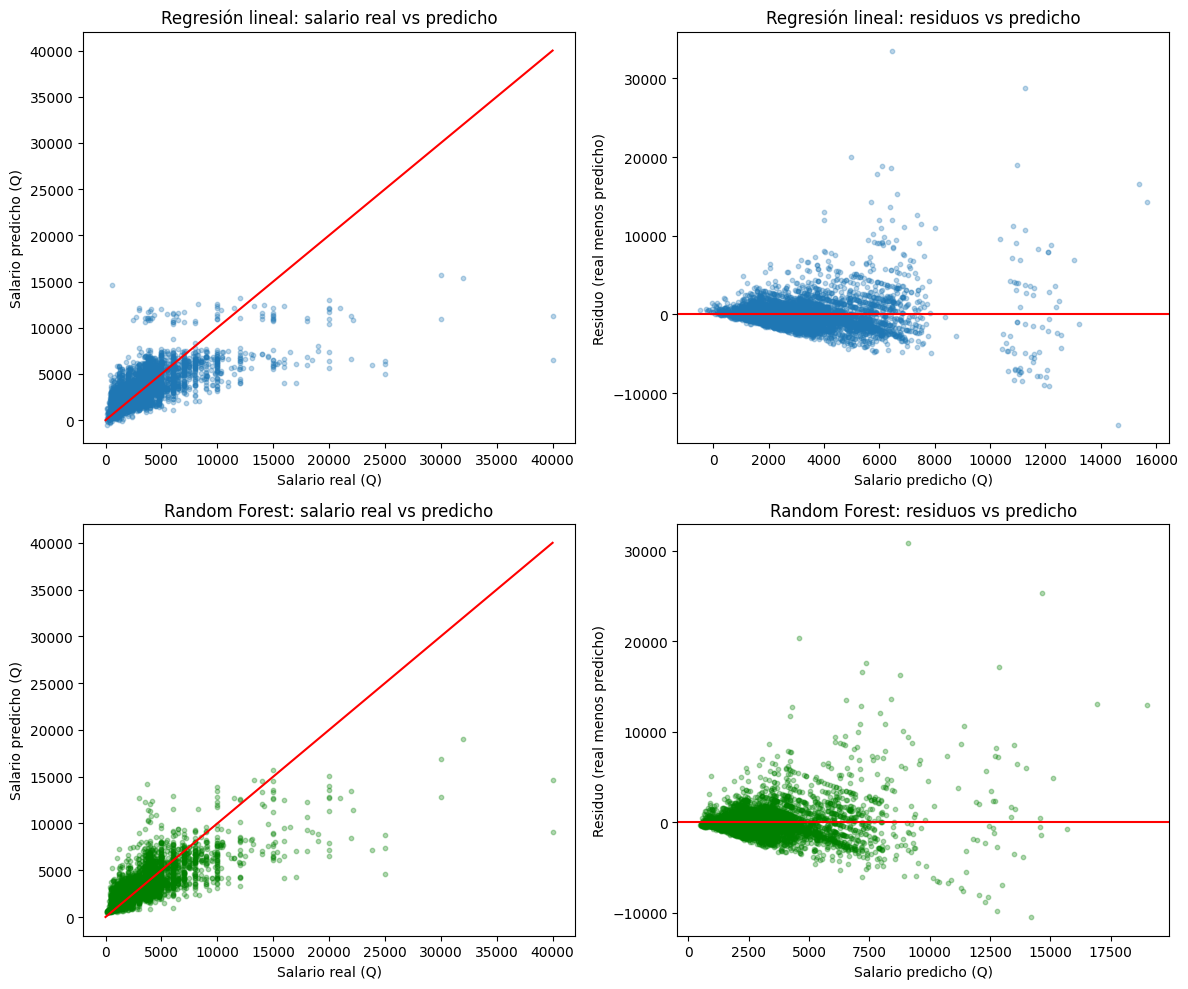

In [35]:
n_test = datos_2026_filtrados.count()

muestra_claves_test = (
    datos_2026_filtrados
    .select("periodo_archivo", "NUM_HOGAR", "NUM_PERSONA")
    .sample(withReplacement=False, fraction=min(1.0, 5000 / n_test), seed=42)
    .limit(5000)
)

muestra_lr_pd = (
    predicciones_lr_test
    .join(muestra_claves_test, on=["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"], how="inner")
    .select("salario_mensual", "prediction")
    .toPandas()
)

muestra_rf_pd = (
    predicciones_rf_test
    .join(muestra_claves_test, on=["periodo_archivo", "NUM_HOGAR", "NUM_PERSONA"], how="inner")
    .select("salario_mensual", "prediction")
    .toPandas()
)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

limite_lr = max(muestra_lr_pd["salario_mensual"].max(), muestra_lr_pd["prediction"].max())
axes[0, 0].scatter(muestra_lr_pd["salario_mensual"], muestra_lr_pd["prediction"], alpha=0.3, s=10)
axes[0, 0].plot([0, limite_lr], [0, limite_lr], color="red")
axes[0, 0].set_title("Regresión lineal: salario real vs predicho")
axes[0, 0].set_xlabel("Salario real (Q)")
axes[0, 0].set_ylabel("Salario predicho (Q)")

residuo_lr = muestra_lr_pd["salario_mensual"] - muestra_lr_pd["prediction"]
axes[0, 1].scatter(muestra_lr_pd["prediction"], residuo_lr, alpha=0.3, s=10)
axes[0, 1].axhline(0, color="red")
axes[0, 1].set_title("Regresión lineal: residuos vs predicho")
axes[0, 1].set_xlabel("Salario predicho (Q)")
axes[0, 1].set_ylabel("Residuo (real menos predicho)")

limite_rf = max(muestra_rf_pd["salario_mensual"].max(), muestra_rf_pd["prediction"].max())
axes[1, 0].scatter(muestra_rf_pd["salario_mensual"], muestra_rf_pd["prediction"], alpha=0.3, s=10, color="green")
axes[1, 0].plot([0, limite_rf], [0, limite_rf], color="red")
axes[1, 0].set_title("Random Forest: salario real vs predicho")
axes[1, 0].set_xlabel("Salario real (Q)")
axes[1, 0].set_ylabel("Salario predicho (Q)")

residuo_rf = muestra_rf_pd["salario_mensual"] - muestra_rf_pd["prediction"]
axes[1, 1].scatter(muestra_rf_pd["prediction"], residuo_rf, alpha=0.3, s=10, color="green")
axes[1, 1].axhline(0, color="red")
axes[1, 1].set_title("Random Forest: residuos vs predicho")
axes[1, 1].set_xlabel("Salario predicho (Q)")
axes[1, 1].set_ylabel("Residuo (real menos predicho)")

plt.tight_layout()
plt.show()

In [36]:
def tabla_errores_por_grupo(predicciones, variable_grupo):
    return (
        predicciones
        .withColumn("residuo", F.col("salario_mensual") - F.col("prediction"))
        .groupBy(variable_grupo)
        .agg(
            F.count("*").alias("n"),
            F.avg(F.abs(F.col("residuo"))).alias("mae"),
            F.avg("residuo").alias("error_medio")
        )
        .orderBy(F.desc("n"))
    )

print("Regresión lineal, error por nivel educativo")
tabla_errores_por_grupo(predicciones_lr_test, "nivel_educativo").show(truncate=False)

print("Regresión lineal, error por dominio")
tabla_errores_por_grupo(predicciones_lr_test, "dominio").show(truncate=False)

print("Random Forest, error por nivel educativo")
tabla_errores_por_grupo(predicciones_rf_test, "nivel_educativo").show(truncate=False)

print("Random Forest, error por dominio")
tabla_errores_por_grupo(predicciones_rf_test, "dominio").show(truncate=False)

Regresión lineal, error por nivel educativo
+---------------+----+------------------+-------------------+
|nivel_educativo|n   |mae               |error_medio        |
+---------------+----+------------------+-------------------+
|4              |4117|1109.3142466276386|103.97732071280305 |
|2              |3957|870.0358173744421 |54.5553590337862   |
|3              |2164|894.4514830552862 |127.76970455270796 |
|5              |1729|2566.3704572105753|295.5140386818375  |
|0              |1016|823.5131164082704 |109.34029889060423 |
|6              |183 |5552.879063507152 |-131.50427745870755|
|1              |80  |735.2063474690456 |88.76187301928807  |
|7              |12  |12919.309265966613|6062.703551890016  |
+---------------+----+------------------+-------------------+

Regresión lineal, error por dominio


+-------+----+------------------+------------------+
|dominio|n   |mae               |error_medio       |
+-------+----+------------------+------------------+
|1      |5632|1446.0925579320754|136.0360907214614 |
|2      |4846|1189.647320374146 |134.28290631738932|
|3      |2780|913.6389300865302 |65.24288669390431 |
+-------+----+------------------+------------------+

Random Forest, error por nivel educativo
+---------------+----+------------------+-------------------+
|nivel_educativo|n   |mae               |error_medio        |
+---------------+----+------------------+-------------------+
|4              |4117|1016.2466004935592|132.79238383415353 |
|2              |3957|755.3931326912675 |37.049792208893315 |
|3              |2164|820.7524039369721 |115.96627752987553 |
|5              |1729|2294.8406464086406|279.49163460494503 |
|0              |1016|653.5210552711235 |-42.78566329668337 |
|6              |183 |4602.897199580975 |-191.158235425871  |
|1              |80  |630.346

+-------+----+------------------+------------------+
|dominio|n   |mae               |error_medio       |
+-------+----+------------------+------------------+
|1      |5632|1318.2287511405302|166.74237669846795|
|2      |4846|1039.9047888887571|88.03930275579103 |
|3      |2780|770.8865865736825 |13.799161118878706|
+-------+----+------------------+------------------+



26/09/27 19:05:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/27 19:05:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/27 19:05:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/27 19:05:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/27 19:05:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/27 19:05:44 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/27 1

26/09/27 19:05:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.
26/09/27 19:05:45 WARN WindowExec: No Partition Defined for Window operation! Moving all data to a single partition, this can cause serious performance degradation.


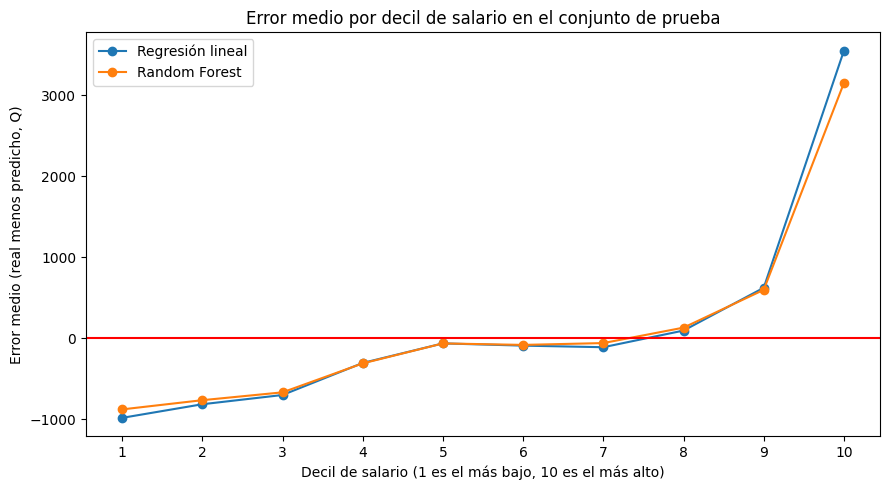

,decil_salario,n,salario_medio,mae,error_medio
0,1,1326,703.509050,1059.237193,-980.811835
1,2,1326,1293.872549,967.442422,-812.846748
2,3,1326,1867.058069,966.287800,-698.754027
3,4,1326,2412.376320,871.244530,-303.689810
4,5,1326,2993.187029,854.482760,-62.455406
5,6,1326,3493.280543,832.996064,-90.004656
6,7,1326,3878.799397,787.217744,-109.533500
7,8,1326,4143.360483,883.166963,95.794051
8,9,1325,5136.410566,1305.547094,623.459427
9,10,1325,9741.944906,3881.523355,3547.316281


In [37]:
from pyspark.sql.window import Window

ventana_decil = Window.orderBy("salario_mensual")

def tabla_errores_por_decil(predicciones):
    return (
        predicciones
        .withColumn("residuo", F.col("salario_mensual") - F.col("prediction"))
        .withColumn("decil_salario", F.ntile(10).over(ventana_decil))
        .groupBy("decil_salario")
        .agg(
            F.count("*").alias("n"),
            F.avg("salario_mensual").alias("salario_medio"),
            F.avg(F.abs(F.col("residuo"))).alias("mae"),
            F.avg("residuo").alias("error_medio")
        )
        .orderBy("decil_salario")
        .toPandas()
    )

deciles_lr = tabla_errores_por_decil(predicciones_lr_test)
deciles_rf = tabla_errores_por_decil(predicciones_rf_test)

plt.figure(figsize=(9, 5))
plt.plot(deciles_lr["decil_salario"], deciles_lr["error_medio"], marker="o", label="Regresión lineal")
plt.plot(deciles_rf["decil_salario"], deciles_rf["error_medio"], marker="o", label="Random Forest")
plt.axhline(0, color="red")
plt.xlabel("Decil de salario (1 es el más bajo, 10 es el más alto)")
plt.ylabel("Error medio (real menos predicho, Q)")
plt.title("Error medio por decil de salario en el conjunto de prueba")
plt.xticks(range(1, 11))
plt.legend()
plt.tight_layout()
plt.show()

deciles_lr

### Discusión final

**Los errores más grandes se concentran en los niveles educativos altos.** En regresión lineal, el nivel educativo código 5 tiene un MAE de Q2,566.37 y un error medio de Q295.51 (subestimación), muy por encima del resto de los niveles, que tienen MAE entre Q735 y Q1,109. El Random Forest reduce ese MAE a Q2,294.84 pero mantiene el mismo patrón. Los códigos 6 y 7 muestran errores aún más grandes, pero con solo 183 y 12 observaciones respectivamente no hay suficiente muestra para sacar conclusiones sólidas sobre esos dos grupos.

**Por dominio, el dominio 1 concentra el error más alto.** Con 5,632 observaciones, tiene un MAE de Q1,446.09 en regresión lineal y Q1,318.23 en Random Forest, más alto que los dominios 2 y 3. Los tres dominios tienen muestra suficiente para confiar en la comparación.

**Los dos modelos subestiman los salarios altos y sobreestiman los más bajos.** En el decil más bajo de salario (media de Q704), el error medio es de -Q980.81 en regresión lineal y -Q870.79 en Random Forest, es decir que ambos modelos predicen más de lo que realmente se gana. El error se acerca a cero entre los deciles 5 y 7, donde está la mayoría del salario mediano. En el decil más alto (media de Q9,742), el error se dispara a +Q3,547.32 en regresión lineal y +Q3,152.10 en Random Forest, la subestimación más grande de toda la tabla, junto con el MAE más alto (por encima de Q3,400 en ambos modelos). Este patrón es esperable en una variable como el salario, que tiene una cola larga hacia arriba, los modelos aprenden a predecir bien la mayoría de los casos comunes, pero no logran seguir a los pocos salarios muy altos.

**En conjunto, las seis variables permiten una estimación moderada del salario, no una predicción precisa.** El Random Forest explica el 53.4% de la variación del salario en 2026T1 y la regresión lineal el 43.1%, ambos muy por encima del modelo de referencia. El cluster 0 del ejercicio 4 (perfil consolidado, con más antigüedad y más presencia de empleados de gobierno) corresponde a las personas con niveles educativos y salarios más altos, que son justamente el grupo donde más se subestima el salario. Esto tiene sentido, mientras más lejos está una persona del perfil típico de asalariado joven y de poca antigüedad, más difícil es para el modelo capturar su salario real.

Este análisis tiene límites claros. Las asociaciones encontradas no son relaciones causales, así que no deben usarse para justificar cuánto debería ganar una persona. La muestra tampoco está ponderada por el factor de expansión, por lo que los resultados describen únicamente a los asalariados con salario positivo que cumplieron los criterios de filtrado en cada período, no a toda la fuerza laboral de Guatemala.